## Demo for modelling single-channel PSF from bead data

#### Setup environment

In [1]:
import sys
sys.path.append("..")
from psflearning.psflearninglib import psflearninglib
from psflearning import io
from psflearning.makeplots import *
import tensorflow as tf
#main_data_dir = io.param.load('datapath.yaml').main_data_dir
try:
    gpus = tf.config.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('Running on GPU')
except:
    print('Running on CPU')

Running on GPU


#### Create psflearning object and load the config file
$\small\color{skyblue}{\mathrm{basefile}}$: config file with all parameters  
$\small\color{skyblue}{\mathrm{psftype}}$:  `'voxel', 'zernike'`  
$\small\color{skyblue}{\mathrm{sysfile}}$: config file with microscope specific parameters  
For advanced user, pass in base file only as below to interact with all parameters:   
```python
    L.param = io.param.combine('config_user')
```

In [11]:
L = psflearninglib()
L.param = io.param.combine('config_base',psftype='zernike',channeltype='2ch',sysfile='smart_tirf')


#### Edit user defined parameters

In [12]:
L.param.datapath = r'T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch/'
L.param.keyword = 'bead2_100nm_darkred_widefield_PBS2025' # keyword for your data file
L.param.savename = L.param.datapath+'result/' + L.param.keyword
L.param.subfolder = '' # keyword for subfolder name if each data file is saved in a individual folder, set to '' if no subfolder
L.param.gain = 0.24 # electron per ADU, this is the gain of the camera, can be found in the camera manual
L.param.ccd_offset = 100
L.param.FOV.z_step = 1  
L.param.pixel_size.z = 0.1 # micron, equal to z_step*stepsize_of_the_data
L.param.roi.max_bead_number = 50 
L.param.roi.bead_radius = 0.0
L.param.ref_channel = 0 # choose the brighter channel as the reference channel, 0 or 1
L.param.batch_size = 30 # lower this number if out of memory
L.param.option.imaging.emission_wavelength = 0.68 # micron
L.param.varname = 'Main/data'


#### Start learning

In [13]:
images = L.load_data()

T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-28-22.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-37-37.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-39-39.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-46-06.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-47-45.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-49-54.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-51-59.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_PBS2025-07-18_17-53-44.h5
T:\projects\smart-microscope\data\psfstack\07-18-2025 2ch\bead2_100nm_darkred_widefield_

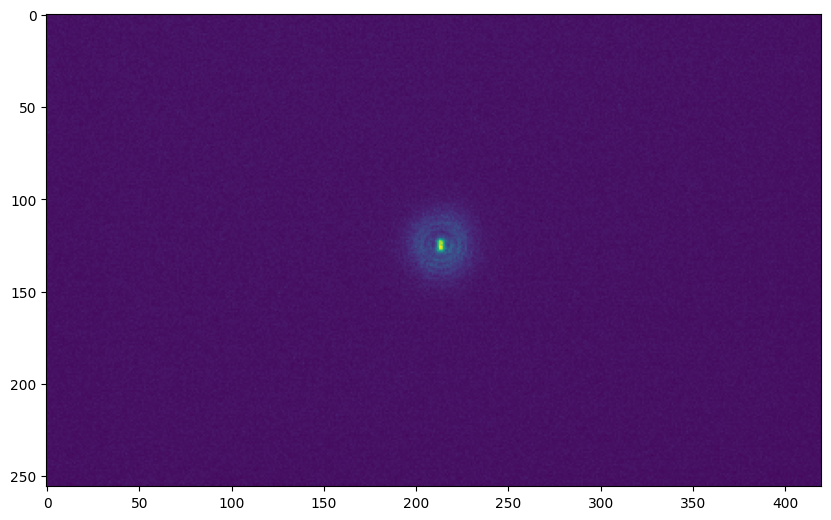

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(images[0][0][0])

In [22]:
L.getpsfclass()
L.param.roi.roi_size = [27,27]
L.param.roi.peak_height = 0.2
L.param.FOV.y_center = 0
L.param.FOV.x_center = 0
L.param.FOV.radius = 0
dataobj = L.prep_data(images)

rois shape channel 0: (17, 21, 27, 27)
rois shape channel 1: (17, 21, 27, 27)
rois shape channel 0: (17, 21, 27, 27)
rois shape channel 1: (17, 21, 27, 27)


In [23]:
#images = L.load_data()
#L.getpsfclass()
#dataobj = L.prep_data(images)
for k in range(0,1): # increase iteration number if necessary
    psfobj,fitter = L.learn_psf(dataobj,time=0)
resfile = L.save_result(psfobj,dataobj,fitter)

3/6: learning: 53/100 [00:02s] 25.36it/s, current loss: 3.04302, total time: 2.08s
3/6: learning: 77/100 [00:02s] 27.90it/s, current loss: 2.93813, total time: 4.84s
3/6: learning: 192/250 [00:14s] 12.98it/s, current loss: 6.14319, total time: 19.63s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.44it/s total time: 21.02s
5/6: localization: 5/5 [00:02s]  1.87it/s total time: 23.70s


outlier id: [ 6 11 12 13 14]
rois shape channel 0: (12, 21, 27, 27)
rois shape channel 1: (12, 21, 27, 27)


3/6: learning: 225/250 [00:16s] 13.37it/s, current loss: 4.46148, total time: 40.53s
4/6: calculating spline coefficients: 2/2 [00:01s]  1.44it/s total time: 41.91s
5/6: localization: 5/5 [00:02s]  1.89it/s total time: 44.56s
6/6: saving results: [00:03s] total time: 47.70s


#### Show results

In [24]:
f,p = io.h5.load(resfile) # load result file

In [38]:
p.pixel_size

{'x': 0.08, 'y': 0.08, 'z': 0.1}

channel 0


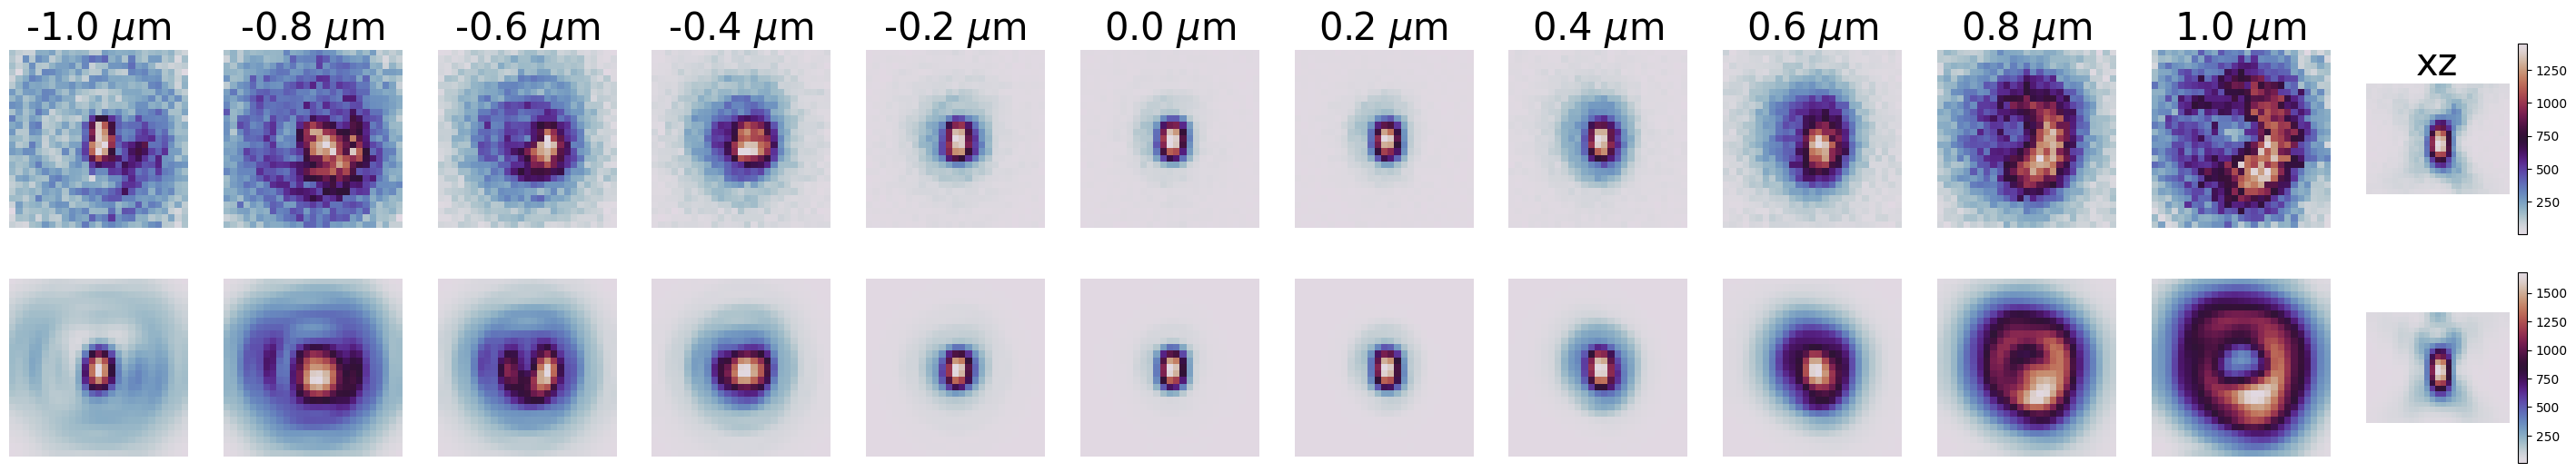

channel 1


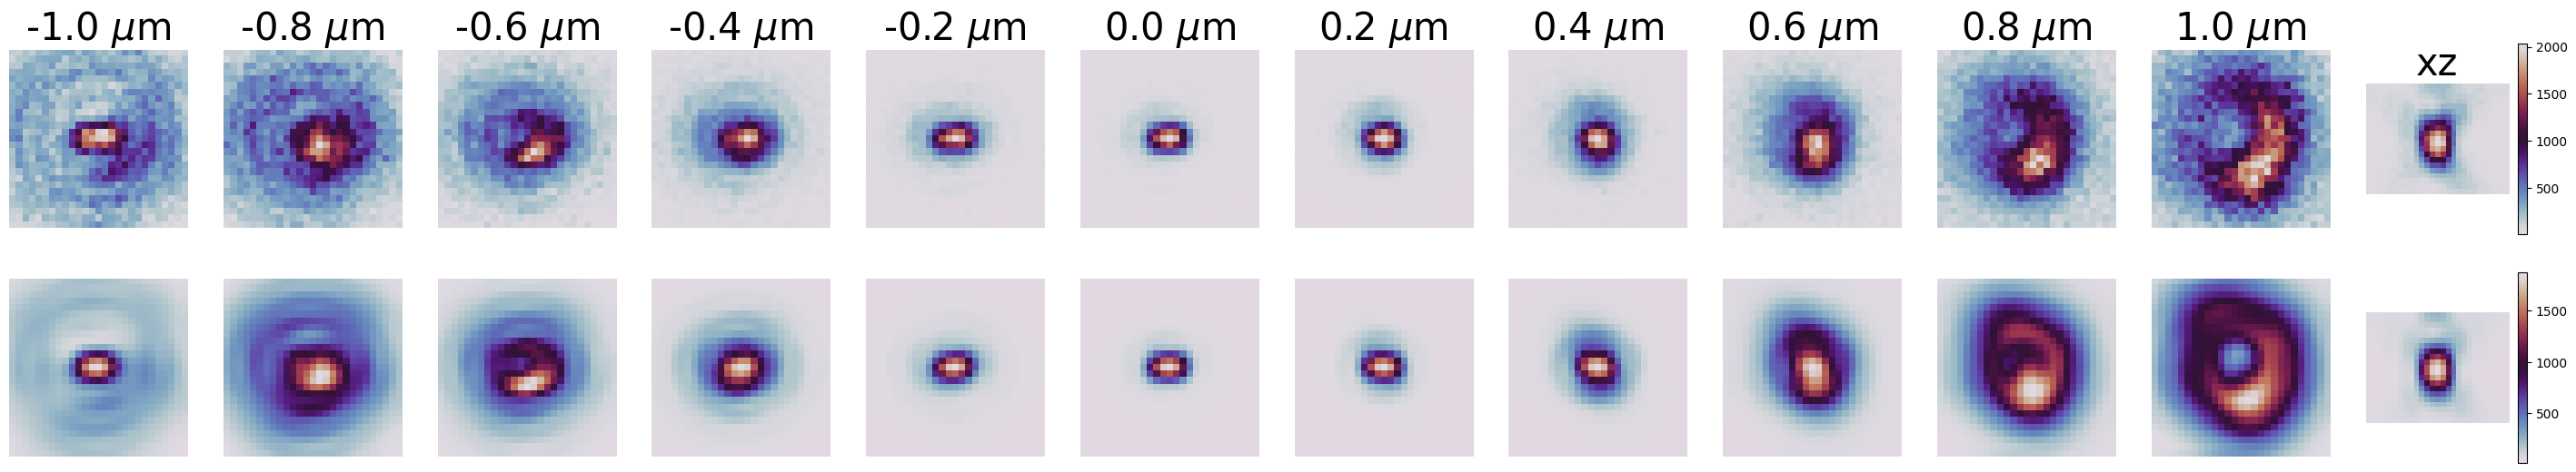

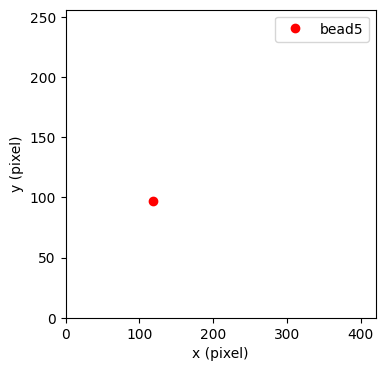

In [30]:
showpsfvsdata(f,p,index=5,step=2)

In [31]:
[f.res.channel0.sigma,f.res.channel1.sigma]

[array([0.67984223, 0.74138224], dtype=float32),
 array([0.7066316, 0.6530305], dtype=float32)]

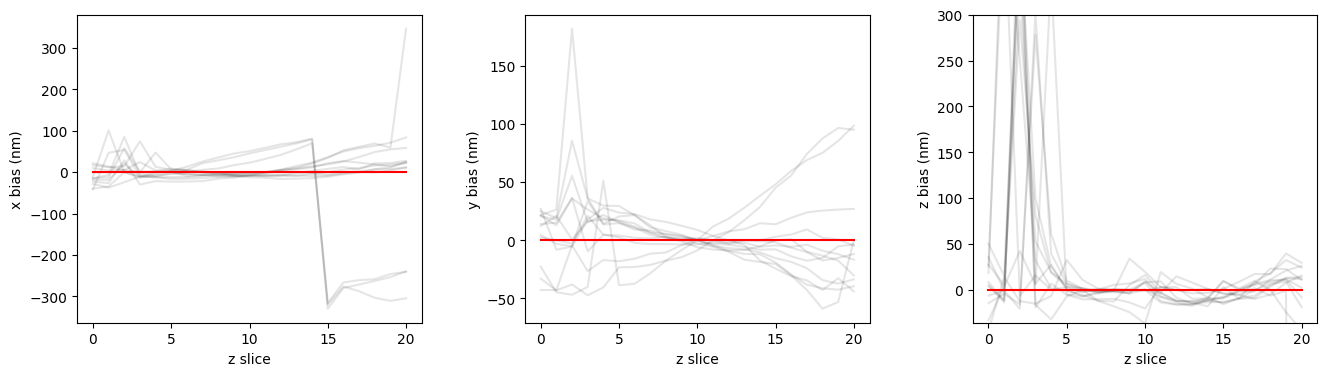

In [32]:
showlocalization(f,p)

#### Optional plots

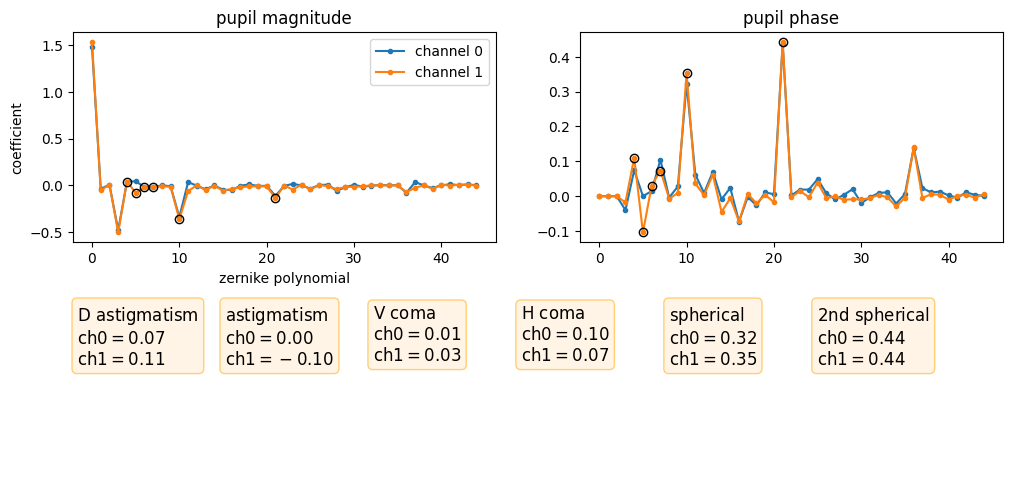

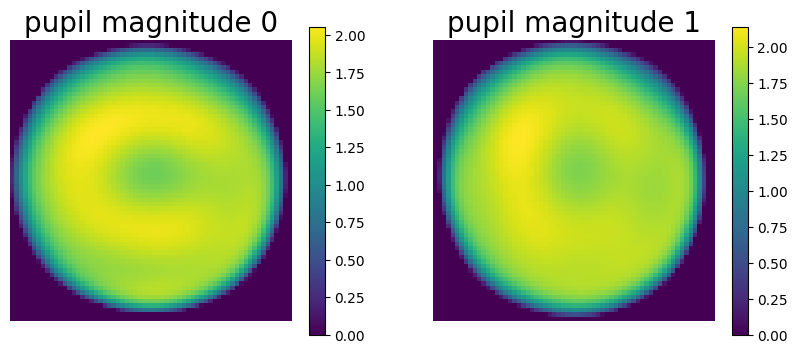

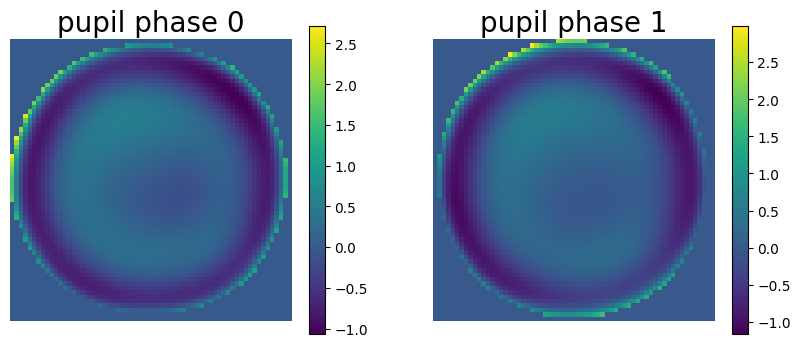

In [33]:
try:
    showzernike(f,p)
except:
    try: 
        showpupil(f,p)
    except:
        print('no pupil')

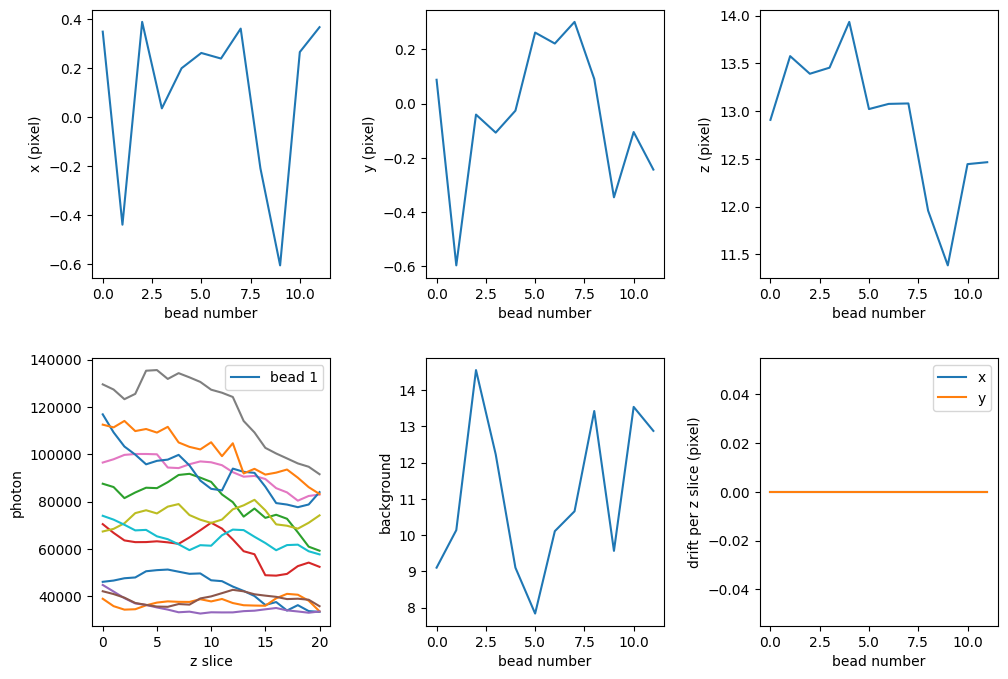

In [34]:
showlearnedparam(f,p)

[[ 0.9971  0.0005 -0.    ]
 [-0.0018  0.9979 -0.    ]
 [-7.5857 18.23    1.    ]]


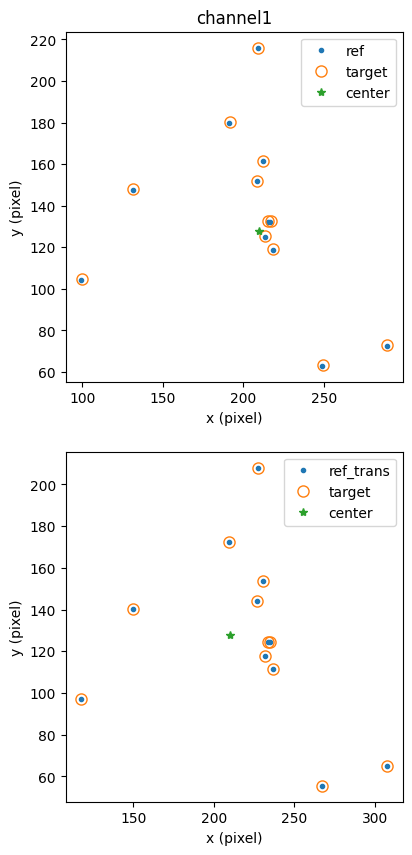

In [35]:
showtransform(f)
np.set_printoptions(precision=4,suppress=True)
print(f.res.T)

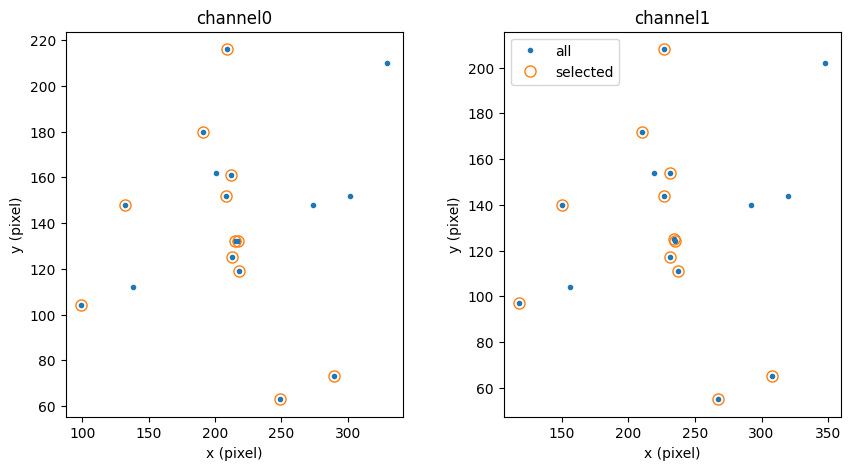

In [36]:
showcoord(f,p)

#### Ouput parameters

In [11]:
print('f:\n    ',list(f.keys()))
print(' locres:\n    ',list(f.locres.keys()))
print(' res:\n    ',list(f.res.keys()))
print(' rois:\n    ',list(f.rois.keys()))

f:
     ['locres', 'res', 'rois']
 locres:
     ['CRLB', 'LL', 'P', 'coeff', 'coeff_bead', 'coeff_reverse', 'loc']
 res:
     ['I_model', 'I_model_bead', 'I_model_reverse', 'apodization', 'bg', 'cor', 'cor_all', 'drift_rate', 'intensity', 'offset', 'pos', 'pupil', 'sigma', 'zernike_coeff', 'zernike_polynomial']
 rois:
     ['cor', 'fileID', 'image_size', 'psf_data', 'psf_fit']
